In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Dropout, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

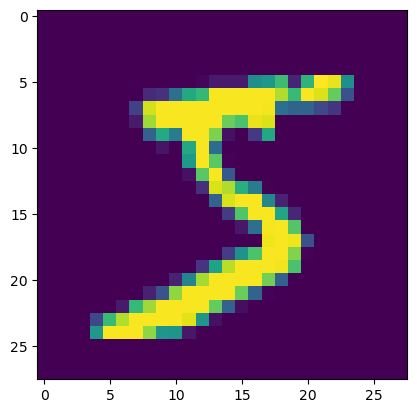

In [3]:
plt.imshow(X_train[0])

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
# Reshape for CNN


X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [6]:
# One Hot Encoding


y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [7]:
# Data Augmentation


datagen = ImageDataGenerator(

    rotation_range=10,

    zoom_range=0.1,

    width_shift_range=0.1,

    height_shift_range=0.1

)

datagen.fit(X_train)

In [9]:
# CNN Model


model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1), strides=(1,1),padding='same',),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Conv2D(64, (3,3),strides=(1,1),padding='same', activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
Dense(10, activation='softmax')

])

In [10]:
# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
   metrics=['accuracy']
)

In [11]:
# Early Stopping


early_stop = EarlyStopping(

    monitor='val_loss',

    patience=3

)

In [12]:
# Train


history = model.fit(

    datagen.flow(X_train,y_train,batch_size=64),

    epochs=15,

    validation_data=(X_test,y_test),

    callbacks=[early_stop]

)

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.8173 - loss: 0.5655 - val_accuracy: 0.9847 - val_loss: 0.0452
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9422 - loss: 0.2020 - val_accuracy: 0.9898 - val_loss: 0.0294
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9548 - loss: 0.1570 - val_accuracy: 0.9910 - val_loss: 0.0262
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9618 - loss: 0.1365 - val_accuracy: 0.9895 - val_loss: 0.0310
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9659 - loss: 0.1219 - val_accuracy: 0.9931 - val_loss: 0.0219
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.9675 - loss: 0.1144 - val_accuracy: 0.9922 - val_loss: 0.0222
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9710 - loss: 0.1050 - val_accuracy: 0.9934 - val_loss: 0.0178
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9720 - loss: 0.1001 - 

In [13]:
# Evaluate


loss, acc = model.evaluate(X_test,y_test)

print("\nFinal Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9932 - loss: 0.0195

Final Accuracy: 0.9932000041007996


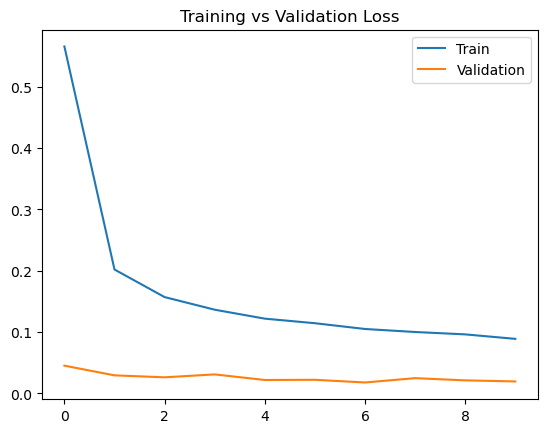

In [14]:
# Plot Loss


plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")

plt.legend(["Train","Validation"])

plt.show()

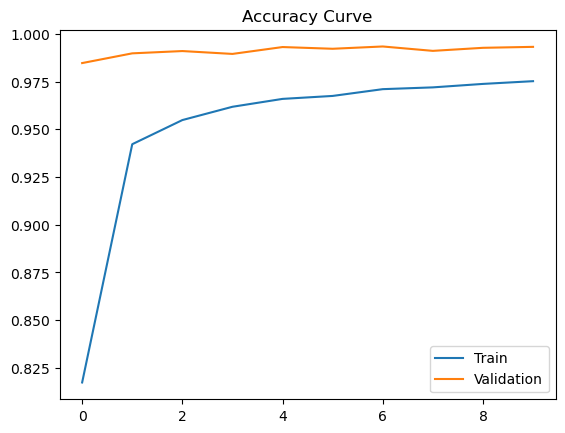

In [15]:
# PLOT ACCURACY

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Curve")

plt.legend(["Train","Validation"])

plt.show()